資料集維度： (506, 13)
前 5 筆資料：
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  
目標欄位前 5 筆：
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64

各欄位缺值數量：
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64

===== Fold 1 =====
MAPE = 0.0953
RMSE = 2.6776
R2   = 0.9022

===== Fold 2 =====
MAPE = 0.0967
RMS

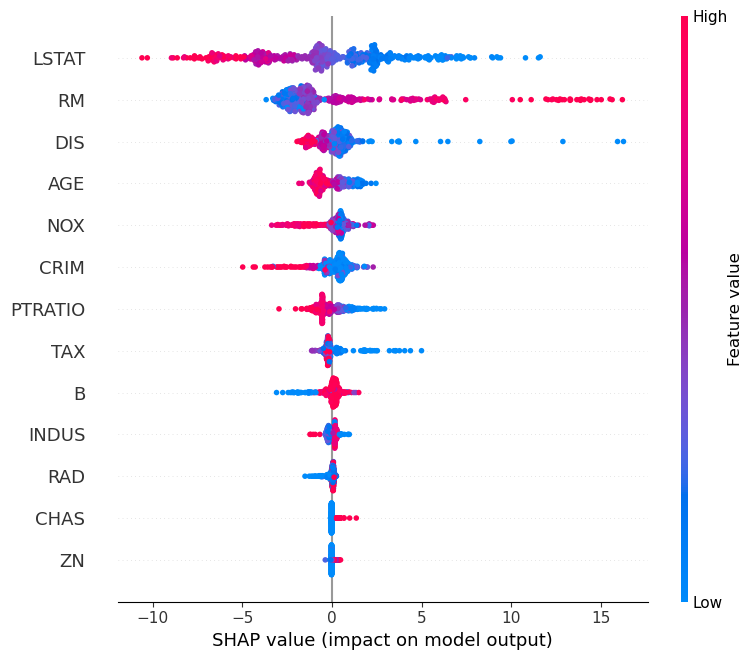


===== SHAP 特徵重要性排序（由大到小） =====
    feature  shap_importance
12    LSTAT         3.151267
5        RM         2.662329
7       DIS         0.808811
6       AGE         0.730719
4       NOX         0.722271
0      CRIM         0.659278
10  PTRATIO         0.650209
9       TAX         0.389450
11        B         0.301842
2     INDUS         0.195806
8       RAD         0.110453
3      CHAS         0.050209
1        ZN         0.045889

保留前 10 個特徵重新訓練： ['LSTAT', 'RM', 'DIS', 'AGE', 'NOX', 'CRIM', 'PTRATIO', 'TAX', 'B', 'INDUS']

===== [前10特徵] Fold 1 =====
MAPE = 0.0972
RMSE = 2.6383
R2   = 0.9051

===== [前10特徵] Fold 2 =====
MAPE = 0.1009
RMSE = 2.9375
R2   = 0.8901

===== [前10特徵] Fold 3 =====
MAPE = 0.1284
RMSE = 3.6752
R2   = 0.8515

===== [前10特徵] Fold 4 =====
MAPE = 0.1083
RMSE = 2.9750
R2   = 0.9153

===== [前10特徵] Fold 5 =====
MAPE = 0.0971
RMSE = 2.5659
R2   = 0.9084

保留前 8 個特徵重新訓練： ['LSTAT', 'RM', 'DIS', 'AGE', 'NOX', 'CRIM', 'PTRATIO', 'TAX']

===== [前8特徵] Fold 1 =====
MAPE = 0.098

In [1]:

"""
資料探勘 作業二 - Boston Housing
使用 XGBoost + 5-fold Cross Validation
並搭配 SHAP 做特徵重要性與特徵篩選比較

說明：
  - 對應作業第二個實驗：
    1) XGBoost + K-fold (K=5)，輸出每一個 fold 的 MAPE、RMSE、R2 以及平均值
    2) 使用 SHAP 計算特徵重要性，做特徵欄位排序與刪減前後績效比較
"""

# ===============================
# 0. 匯入所需套件
# ===============================
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

RANDOM_SEED = 42  # 固定亂數種子，讓結果可重現

# ===============================
# 1. 讀取資料集 + 基本前置處理  (對應報告 3.1、3.2)
# ===============================

# --- 方法 A：使用 fetch_openml 自動下載 Boston Housing ---
USE_OPENML = True   # 若要改用自己下載的 CSV，就設為 False

if USE_OPENML:
    # 1-1 透過 OpenML 下載 Boston Housing 資料集
    boston = fetch_openml(name='boston', version=1, as_frame=True)
    X = boston.data        # 13 個特徵欄位
    y = boston.target      # 目標欄位 MEDV（房價中位數）

    # OpenML 的 target 可能是字串，先轉成 float
    y = y.astype(float)

else:
    # --- 方法 B：讀取本機 CSV 檔 ---
    # 假設 boston.csv 與這支程式放在同一個資料夾
    df = pd.read_csv("boston.csv")

    # 目標欄位名稱請依你的 CSV 調整，通常為 "MEDV" 或 "medv"
    target_col = "MEDV"
    X = df.drop(columns=[target_col])
    y = df[target_col]

# 顯示資料基本資訊
print("資料集維度：", X.shape)   # (筆數, 特徵數)
print("前 5 筆資料：")
print(X.head())
print("目標欄位前 5 筆：")
print(y.head())

# 1-2 缺值檢查
print("\n各欄位缺值數量：")
print(X.isnull().sum())

# 1-3 如果有 CHAS 欄位（是否鄰近河流），轉為整數型態（有助於說明前置處理）
if "CHAS" in X.columns:
    X = X.copy()
    X["CHAS"] = X["CHAS"].astype(int)

# 1-4 特徵標準化（Z-score），XGBoost 不一定需要，但報告可以寫有做正規化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 轉回 DataFrame 方便後續用欄位名稱
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# ===============================
# 2. 建立 XGBoost + 5-fold Cross Validation  (對應報告 3.3 3.4)
# ===============================

# 建立 5-fold 的 KFold 物件
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

mape_scores = []
rmse_scores = []
r2_scores = []

fold_id = 1

for train_index, test_index in kf.split(X_scaled):
    print(f"\n===== Fold {fold_id} =====")

    X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # 建立 XGBoost 回歸模型
    model = XGBRegressor(
        n_estimators=200,        # 樹的數量
        learning_rate=0.1,      # 學習率
        max_depth=4,            # 樹的最大深度
        subsample=0.8,          # 每棵樹使用的樣本比例
        colsample_bytree=0.8,   # 每棵樹使用的特徵比例
        random_state=RANDOM_SEED,
        n_jobs=-1               # 使用所有 CPU 核心
    )

    # 訓練模型
    model.fit(X_train, y_train)

    # 在測試資料上進行預測
    y_pred = model.predict(X_test)

    # 計算三個績效指標：MAPE、RMSE、R2
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"MAPE = {mape:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R2   = {r2:.4f}")

    mape_scores.append(mape)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    fold_id += 1

# 2-2 計算五個 folds 的平均績效
print("\n===== 5 folds 平均績效 =====")
print(f"MAPE 平均值 = {np.mean(mape_scores):.4f}")
print(f"RMSE 平均值 = {np.mean(rmse_scores):.4f}")
print(f"R2   平均值 = {np.mean(r2_scores):.4f}")

# 若想把結果存成 CSV 表格，可以另外加：
# result_df = pd.DataFrame({
#     "Fold": list(range(1, 6)),
#     "MAPE": mape_scores,
#     "RMSE": rmse_scores,
#     "R2": r2_scores
# })
# result_df.to_csv("boston_xgb_cv_result.csv", index=False)


# ===============================
# 3. 使用 SHAP 計算特徵重要性  (對應報告 3.5)
# ===============================

# 為了做 SHAP，這裡用全部資料重新訓練一個模型（使用 13 個原始特徵）
full_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
full_model.fit(X_scaled, y)

print("\n===== 進行 SHAP 特徵重要性分析 =====")

# 1. 把資料轉成 XGBoost 的 DMatrix 格式（與訓練時相同的 X_scaled）
dtrain = xgb.DMatrix(X_scaled, label=y)

# 2. 從 sklearn 介面的 full_model 取出真正的 booster
booster = full_model.get_booster()

# 3. 使用 XGBoost 內建的 SHAP 計算（pred_contribs=True）
#    輸出 shape = (樣本數, 特徵數 + 1)，最後一欄為 bias 項
shap_values = booster.predict(dtrain, pred_contribs=True)

# 4. 去掉最後一欄 bias，只保留各特徵的 SHAP 值
shap_values_no_bias = shap_values[:, :-1]

# 5. 畫出 SHAP summary plot（可以放在報告 3.4）
plt.figure()
shap.summary_plot(
    shap_values_no_bias,
    X_scaled,
    feature_names=X_scaled.columns,
    max_display=X_scaled.shape[1],   # 顯示所有特徵
    show=True
)

# 6. 計算每個特徵「絕對 SHAP 值的平均」，作為重要性分數
abs_mean_shap = np.abs(shap_values_no_bias).mean(axis=0)
feature_importance = pd.DataFrame({
    "feature": X_scaled.columns,
    "shap_importance": abs_mean_shap
}).sort_values(by="shap_importance", ascending=False)

print("\n===== SHAP 特徵重要性排序（由大到小） =====")
print(feature_importance)


# ===============================
# 4. 依 SHAP 排名做特徵刪減，再重做 5-fold  (對應報告 3.6)
# ===============================
# 這裡示範：
#   - 原始：13 個特徵（你前面已經做過，存在 mape_scores / rmse_scores / r2_scores）
#   - 刪除 3 個特徵：只保留前 10 名
#   - 刪除 5 個特徵：只保留前 8 名
# 之後可在報告中比較三種模型的績效差異

def eval_with_selected_features(selected_features, label):
    """給定要保留的特徵名稱清單，用 KFold 重新訓練並回傳三個指標平均值。"""
    X_sub = X_scaled[selected_features]

    mape_list = []
    rmse_list = []
    r2_list = []

    fold_id = 1
    for train_index, test_index in kf.split(X_sub):
        print(f"\n===== [{label}] Fold {fold_id} =====")

        X_train, X_test = X_sub.iloc[train_index], X_sub.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = XGBRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mape = mean_absolute_percentage_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2    = r2_score(y_test, y_pred)

        print(f"MAPE = {mape:.4f}")
        print(f"RMSE = {rmse:.4f}")
        print(f"R2   = {r2:.4f}")

        mape_list.append(mape)
        rmse_list.append(rmse)
        r2_list.append(r2)

        fold_id += 1

    return np.mean(mape_list), np.mean(rmse_list), np.mean(r2_list)


# 原始 13 特徵的平均績效（前面已經算過）
orig_mape_mean = np.mean(mape_scores)
orig_rmse_mean = np.mean(rmse_scores)
orig_r2_mean   = np.mean(r2_scores)

# 依 SHAP 排名，取前 10 / 前 8 個特徵
top10_features = feature_importance.head(10)["feature"].tolist()
top8_features  = feature_importance.head(8)["feature"].tolist()

print("\n保留前 10 個特徵重新訓練：", top10_features)
top10_mape, top10_rmse, top10_r2 = eval_with_selected_features(top10_features, "前10特徵")

print("\n保留前 8 個特徵重新訓練：", top8_features)
top8_mape, top8_rmse, top8_r2 = eval_with_selected_features(top8_features, "前8特徵")

print("\n===== 不同特徵數模型 5 folds 平均績效 =====")
print(f"原始 13 特徵：MAPE={orig_mape_mean:.4f}, RMSE={orig_rmse_mean:.4f}, R2={orig_r2_mean:.4f}")
print(f"前 10 特徵： MAPE={top10_mape:.4f}, RMSE={top10_rmse:.4f}, R2={top10_r2:.4f}")
print(f"前 8 特徵：  MAPE={top8_mape:.4f}, RMSE={top8_rmse:.4f}, R2={top8_r2:.4f}")

# 做成比較表，方便貼到報告
compare_df = pd.DataFrame({
    "模型版本": ["原始 13 特徵", "刪除 3 特徵 (前10)", "刪除 5 特徵 (前8)"],
    "MAPE 平均": [orig_mape_mean, top10_mape, top8_mape],
    "RMSE 平均": [orig_rmse_mean, top10_rmse, top8_rmse],
    "R2 平均":   [orig_r2_mean,   top10_r2,   top8_r2]
})
print("\n===== 原始 vs 特徵刪減 模型績效比較 =====")
print(compare_df)
# 若需要，也可以存成 CSV：
#compare_df.to_csv("boston_xgb_compare.csv", index=False,encoding='utf-8-sig')

